# Variational Autoencoders (VAEs) with MNIST

## A Patient Teacher's Guide to Understanding VAEs

Welcome! In this notebook, we'll explore Variational Autoencoders (VAEs) using the MNIST dataset. VAEs are powerful generative models that learn to encode data into a meaningful latent space and generate new samples.

![](https://github.com/andandandand/generative-ai-with-diffusion-models-resources/blob/main/images/VAEs.png?raw=true)

### What Makes VAEs Special?

As the diagram shows, VAEs look cleaner and simpler than many other architectures! If you've followed along with U-Nets and diffusion models, you'll have no problem picking up VAEs.

Like other autoencoders, VAEs split the model between an **encoder** and a **decoder**. Here's what's clever:

1. **Probabilistic Encoding**: Instead of encoding to a single point, the encoder outputs two vectors - mean (μ) and standard deviation (σ)
2. **Latent Distribution**: We assume our latent variables follow a normal distribution
3. **Meaningful Representation**: The model learns to represent image features as deviations from the feature average

### Learning Objectives
- Understand the VAE architecture and its probabilistic foundation
- Implement encoder and decoder networks with the reparameterization trick
- Train a VAE on MNIST and explore its capabilities
- Compare VAEs with DDPMs and understand their trade-offs

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Data Preparation

We'll use the classic MNIST dataset - handwritten digits from 0 to 9. Each image is 28×28 pixels.

In [ ]:
# Data loading and preprocessing
def load_mnist_data(batch_size=128):
    """Load and prepare MNIST dataset for VAE training."""

    # Transform to tensor and normalize to [0, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    # Load training and test datasets
    train_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=False,
        transform=transform,
        download=True
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# Load the data
BATCH_SIZE = 128
train_loader, test_loader = load_mnist_data(BATCH_SIZE)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of batches: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]

Training samples: 60000
Test samples: 10000
Batch size: 128
Number of batches: 469


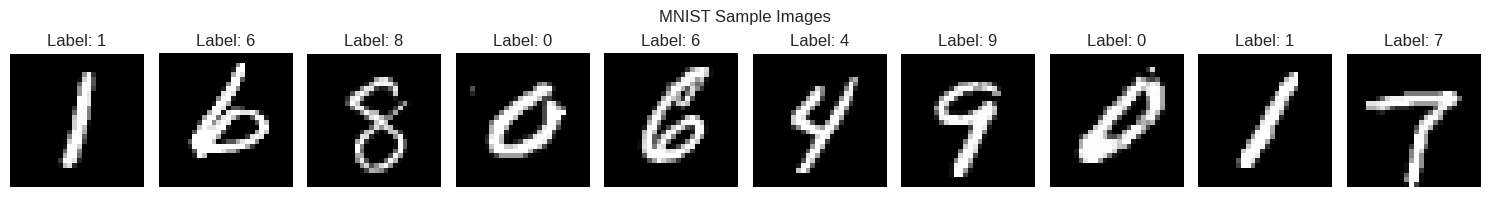

In [ ]:
# Visualize some samples
def show_mnist_samples(loader, num_samples=10):
    """Display sample images from the dataset."""
    data_iter = iter(loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
    for i in range(num_samples):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {labels[i].item()}')
        axes[i].axis('off')
    plt.suptitle('MNIST Sample Images')
    plt.tight_layout()
    plt.show()

show_mnist_samples(train_loader)

## 2. VAE Architecture Implementation

Now let's implement the VAE architecture as shown in the diagram:

### Key Components:

1. **Encoder**: Maps input $x$ to latent parameters $(\mu, \log\sigma^2)$
2. **Reparameterization**: Sample $z = \mu + \sigma \cdot \epsilon$ where $\epsilon \sim \mathcal{N}(0,1)$
3. **Decoder**: Maps latent $z$ back to reconstruction $\hat{x}$

### The Reparameterization Trick

The clever trick that makes VAEs trainable is the reparameterization:
- Instead of sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ directly (non-differentiable)
- We compute $z = \mu + \sigma \cdot \epsilon$ where $\epsilon \sim \mathcal{N}(0,1)$
- This makes the sampling differentiable with respect to $\mu$ and $\sigma$!

In [ ]:
class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST.
    Architecture matches the provided diagram:
    - Encoder: Conv layers → Flatten → Dense → (μ, log_σ²)
    - Decoder: Dense → Unflatten → ConvTranspose layers
    """

    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ============ ENCODER ============
        # Following the diagram: Feature Map (Down) → Feature Map (Down1) → Feature Map (Down2)

        # Encoder convolutional layers
        self.encoder_conv = nn.Sequential(
            # First down block: 28x28x1 → 14x14x32
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Second down block: 14x14x32 → 7x7x64
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Third down block: 7x7x64 → 4x4x128
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Calculate flattened dimension
        self.flatten_dim = 128 * 4 * 4  # After three stride-2 convolutions from 28x28

        # Encoder fully connected layers for μ and log(σ²)
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # ============ DECODER ============
        # Following the diagram: Feature Map (Up0) → Feature Map (Up1) → Feature Map (Up2)

        # Decoder fully connected layer
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, self.flatten_dim),
            nn.ReLU()
        )

        # Decoder convolutional layers
        self.decoder_conv = nn.Sequential(
            # First up block: 4x4x128 → 7x7x64
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Second up block: 7x7x64 → 14x14x32
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Third up block: 14x14x32 → 28x28x1
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for BCE loss
        )

    def encode(self, x):
        """Encode input to latent parameters μ and log(σ²)."""
        # Convolutional encoding
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)  # Flatten

        # Output mean and log variance
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = μ + σ * ε
        where ε ~ N(0, 1)
        """
        if self.training:
            std = torch.exp(0.5 * logvar)  # σ = exp(0.5 * log(σ²))
            eps = torch.randn_like(std)    # ε ~ N(0, 1)
            z = mu + eps * std              # z = μ + σ * ε
            return z
        else:
            # During inference, use mean
            return mu

    def decode(self, z):
        """Decode latent vector to reconstructed image."""
        # Fully connected decoding
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 128, 4, 4)  # Unflatten

        # Convolutional decoding
        x_recon = self.decoder_conv(h)

        return x_recon

    def forward(self, x):
        """Full forward pass through VAE."""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def sample(self, num_samples=1):
        """Generate new samples from the prior p(z) = N(0, 1)."""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

# Initialize the model
LATENT_DIM = 20
model = VAE(latent_dim=LATENT_DIM).to(device)
print(f"VAE initialized with latent dimension: {LATENT_DIM}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE initialized with latent dimension: 20
Total parameters: 310,825


## 3. Loss Function: The Evidence Lower Bound (ELBO)

The VAE loss consists of two terms:

$$\mathcal{L} = \mathcal{L}_{recon} + \beta \cdot \mathcal{L}_{KL}$$

1. **Reconstruction Loss** $\mathcal{L}_{recon}$: How well we reconstruct the input
   - Binary Cross-Entropy for MNIST (pixel values in [0,1])

2. **KL Divergence** $\mathcal{L}_{KL}$: Regularization term
   - Ensures the latent distribution stays close to $\mathcal{N}(0, 1)$
   - Closed form: $\mathcal{L}_{KL} = -\frac{1}{2}\sum_{j=1}^{J}(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2)$

The $\beta$ parameter controls the trade-off (β-VAE when β ≠ 1).

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    Calculate the VAE loss (negative ELBO).

    Args:
        x_recon: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence term (β-VAE)

    Returns:
        total_loss, recon_loss, kl_loss
    """
    # Reconstruction loss (Binary Cross-Entropy)
    # Sum over all pixels, average over batch
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)

    # KL divergence loss
    # KL(q(z|x) || p(z)) where p(z) = N(0, 1)
    # Closed form: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

## 4. Training the VAE

Now let's train our VAE! We'll monitor both reconstruction and KL losses to understand the learning dynamics.

In [ ]:
def train_vae(model, train_loader, test_loader, num_epochs=10, learning_rate=1e-3, beta=1.0):
    """
    Train the VAE model.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = {'total': [], 'recon': [], 'kl': []}
    test_losses = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss_total = 0
        train_loss_recon = 0
        train_loss_kl = 0

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()

            # Forward pass
            x_recon, mu, logvar = model(data)

            # Calculate loss
            loss, recon_loss, kl_loss = vae_loss(x_recon, data, mu, logvar, beta)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Accumulate losses
            train_loss_total += loss.item()
            train_loss_recon += recon_loss.item()
            train_loss_kl += kl_loss.item()

            # Print progress
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1}/{num_epochs} [{batch_idx}/{len(train_loader)}] '
                      f'Loss: {loss.item():.4f} (Recon: {recon_loss.item():.4f}, '
                      f'KL: {kl_loss.item():.4f})')

        # Calculate average training losses
        avg_train_total = train_loss_total / len(train_loader)
        avg_train_recon = train_loss_recon / len(train_loader)
        avg_train_kl = train_loss_kl / len(train_loader)

        train_losses['total'].append(avg_train_total)
        train_losses['recon'].append(avg_train_recon)
        train_losses['kl'].append(avg_train_kl)

        # Testing
        model.eval()
        test_loss_total = 0
        test_loss_recon = 0
        test_loss_kl = 0

        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                x_recon, mu, logvar = model(data)
                loss, recon_loss, kl_loss = vae_loss(x_recon, data, mu, logvar, beta)

                test_loss_total += loss.item()
                test_loss_recon += recon_loss.item()
                test_loss_kl += kl_loss.item()

        # Calculate average test losses
        avg_test_total = test_loss_total / len(test_loader)
        avg_test_recon = test_loss_recon / len(test_loader)
        avg_test_kl = test_loss_kl / len(test_loader)

        test_losses['total'].append(avg_test_total)
        test_losses['recon'].append(avg_test_recon)
        test_losses['kl'].append(avg_test_kl)

        print(f'\nEpoch {epoch+1}/{num_epochs} Summary:')
        print(f'  Train Loss: {avg_train_total:.4f} (Recon: {avg_train_recon:.4f}, KL: {avg_train_kl:.4f})')
        print(f'  Test Loss:  {avg_test_total:.4f} (Recon: {avg_test_recon:.4f}, KL: {avg_test_kl:.4f})')
        print('-' * 70)

    return train_losses, test_losses

# Train the model
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
BETA = 1.0  # Standard VAE (use β > 1 for β-VAE)

print(f"Starting training for {NUM_EPOCHS} epochs...\n")
train_losses, test_losses = train_vae(model, train_loader, test_loader,
                                      NUM_EPOCHS, LEARNING_RATE, BETA)

Starting training for 10 epochs...

Epoch 1/10 [0/469] Loss: 659.4550 (Recon: 656.8950, KL: 2.5601)
Epoch 1/10 [100/469] Loss: 182.5836 (Recon: 166.4635, KL: 16.1201)
Epoch 1/10 [200/469] Loss: 135.9362 (Recon: 115.0678, KL: 20.8683)
Epoch 1/10 [300/469] Loss: 124.0925 (Recon: 100.1010, KL: 23.9915)
Epoch 1/10 [400/469] Loss: 118.1021 (Recon: 93.5655, KL: 24.5366)

Epoch 1/10 Summary:
  Train Loss: 166.5031 (Recon: 146.5412, KL: 19.9618)
  Test Loss:  106.3400 (Recon: 82.0854, KL: 24.2545)
----------------------------------------------------------------------
Epoch 2/10 [0/469] Loss: 117.2291 (Recon: 92.7777, KL: 24.4514)
Epoch 2/10 [100/469] Loss: 110.6943 (Recon: 85.8455, KL: 24.8488)
Epoch 2/10 [200/469] Loss: 115.2075 (Recon: 90.2412, KL: 24.9663)
Epoch 2/10 [300/469] Loss: 112.0631 (Recon: 87.2025, KL: 24.8606)
Epoch 2/10 [400/469] Loss: 113.9987 (Recon: 87.7581, KL: 26.2406)

Epoch 2/10 Summary:
  Train Loss: 111.9905 (Recon: 87.1824, KL: 24.8081)
  Test Loss:  99.6477 (Recon: 74

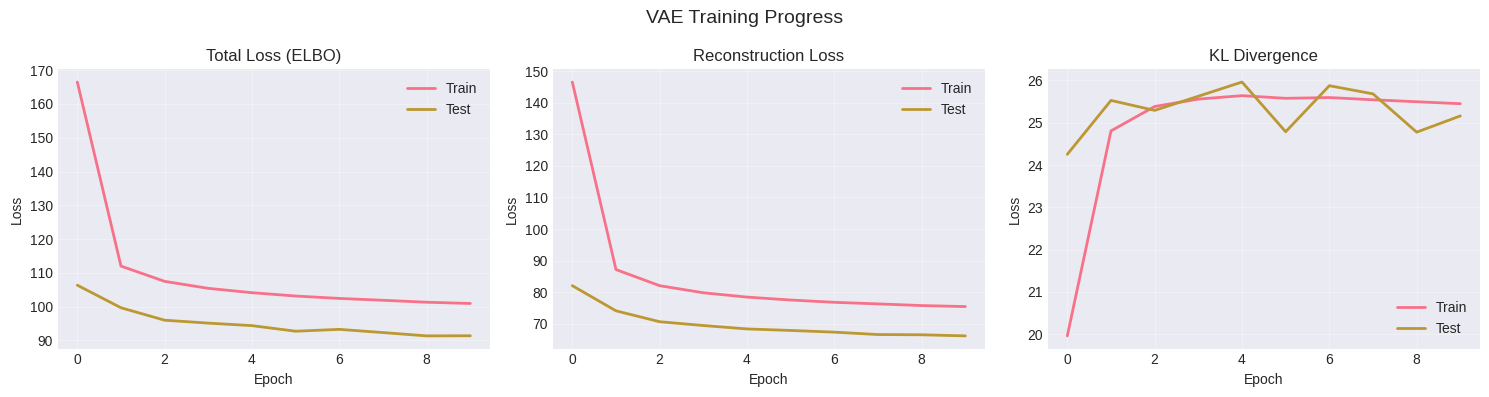

In [ ]:
# Plot training curves
def plot_training_curves(train_losses, test_losses):
    """Visualize training and test losses over epochs."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Total loss
    axes[0].plot(train_losses['total'], label='Train', linewidth=2)
    axes[0].plot(test_losses['total'], label='Test', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Total Loss (ELBO)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Reconstruction loss
    axes[1].plot(train_losses['recon'], label='Train', linewidth=2)
    axes[1].plot(test_losses['recon'], label='Test', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Reconstruction Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # KL divergence
    axes[2].plot(train_losses['kl'], label='Train', linewidth=2)
    axes[2].plot(test_losses['kl'], label='Test', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('KL Divergence')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('VAE Training Progress', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, test_losses)

## 5. Visualizing VAE Capabilities

Let's explore what our trained VAE can do!

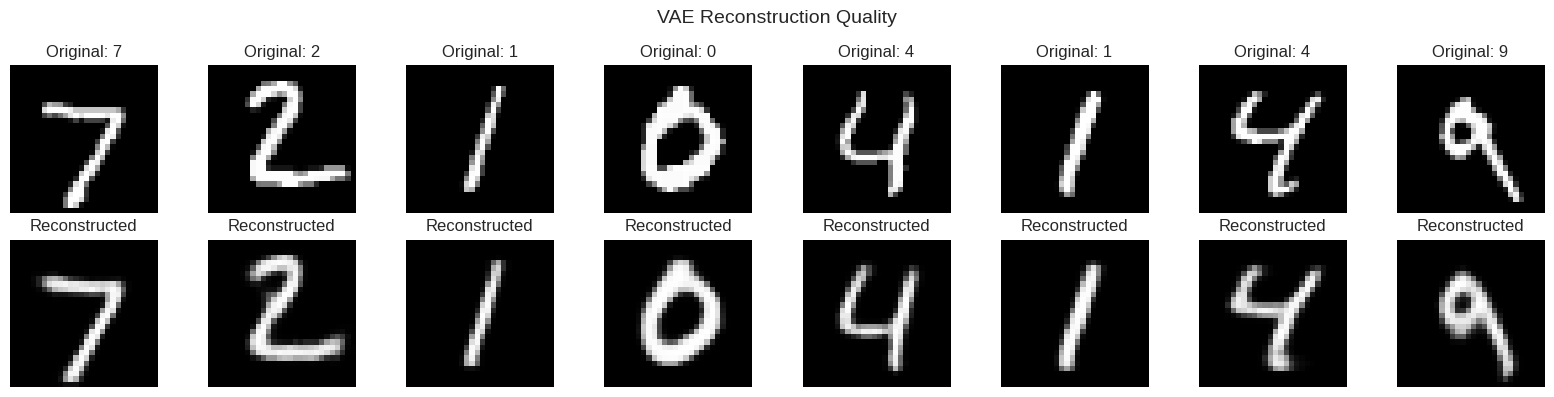

In [ ]:
# Test reconstruction quality
@torch.no_grad()
def visualize_reconstruction(model, loader, num_samples=8):
    """Compare original images with their VAE reconstructions."""
    model.eval()

    # Get a batch of test images
    data_iter = iter(loader)
    images, labels = next(data_iter)
    images = images[:num_samples].to(device)

    # Reconstruct
    recon, mu, logvar = model(images)

    # Plot
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples*2, 4))

    for i in range(num_samples):
        # Original
        axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axes[0, i].set_title(f'Original: {labels[i].item()}')
        axes[0, i].axis('off')

        # Reconstruction
        axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    plt.suptitle('VAE Reconstruction Quality', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_reconstruction(model, test_loader)

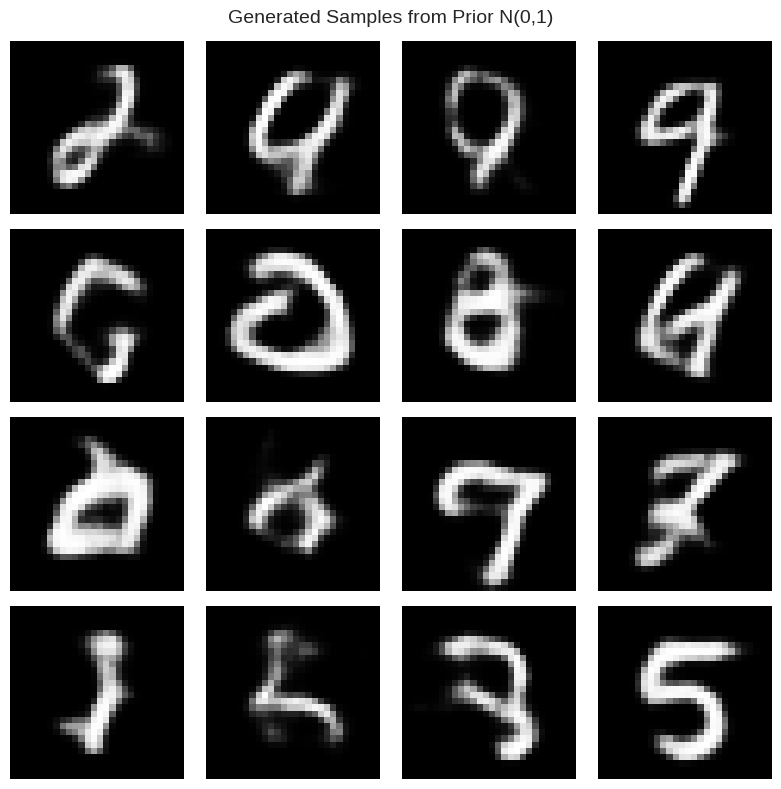

In [ ]:
# Generate new samples from the prior
@torch.no_grad()
def generate_samples(model, num_samples=16):
    """Generate new digits by sampling from the prior N(0, 1)."""
    model.eval()

    # Sample from prior
    samples = model.sample(num_samples)

    # Plot
    n_cols = int(np.sqrt(num_samples))
    n_rows = num_samples // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    axes = axes.flatten()

    for i in range(num_samples):
        axes[i].imshow(samples[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')

    plt.suptitle('Generated Samples from Prior N(0,1)', fontsize=14)
    plt.tight_layout()
    plt.show()

generate_samples(model, 16)

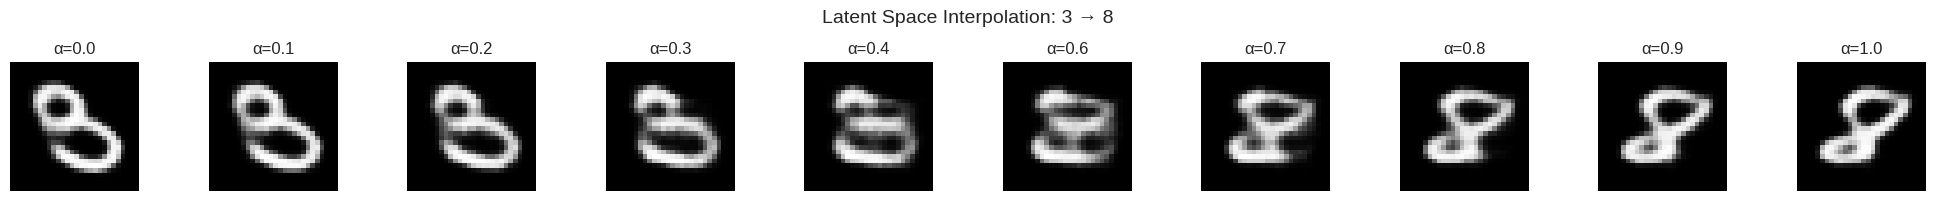

In [ ]:
# Latent space interpolation
@torch.no_grad()
def interpolate_digits(model, loader, digit1=0, digit2=8, steps=10):
    """Interpolate between two digits in latent space."""
    model.eval()

    # Find examples of the two digits
    img1, img2 = None, None

    for data, labels in loader:
        idx1 = (labels == digit1).nonzero(as_tuple=True)[0]
        idx2 = (labels == digit2).nonzero(as_tuple=True)[0]

        if len(idx1) > 0 and img1 is None:
            img1 = data[idx1[0:1]].to(device)
        if len(idx2) > 0 and img2 is None:
            img2 = data[idx2[0:1]].to(device)

        if img1 is not None and img2 is not None:
            break

    # Encode to latent space
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    # Interpolate in latent space
    fig, axes = plt.subplots(1, steps, figsize=(steps*2, 2))

    for i, alpha in enumerate(np.linspace(0, 1, steps)):
        # Linear interpolation: z = (1-α)z₁ + αz₂
        z_interp = (1 - alpha) * mu1 + alpha * mu2

        # Decode
        img_interp = model.decode(z_interp)

        # Plot
        axes[i].imshow(img_interp.cpu().squeeze(), cmap='gray')
        axes[i].set_title(f'α={alpha:.1f}')
        axes[i].axis('off')

    plt.suptitle(f'Latent Space Interpolation: {digit1} → {digit2}', fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate_digits(model, test_loader, digit1=3, digit2=8)

Training a 2D latent VAE for visualization...
2D VAE - Epoch 1/5, Loss: 201.2327
2D VAE - Epoch 3/5, Loss: 155.5553
2D VAE - Epoch 5/5, Loss: 151.6101


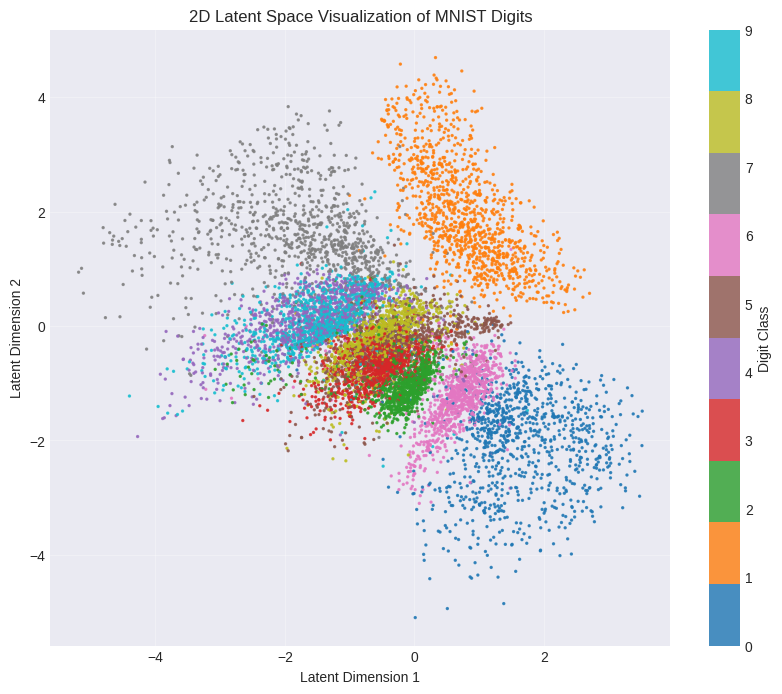

In [ ]:
# Visualize 2D latent space (requires training a 2D latent VAE)
def visualize_2d_latent_space():
    """Train a VAE with 2D latent space for visualization."""
    print("Training a 2D latent VAE for visualization...")

    # Create a new model with 2D latent space
    vae_2d = VAE(latent_dim=2).to(device)

    # Quick training (fewer epochs for demo)
    optimizer = optim.Adam(vae_2d.parameters(), lr=1e-3)

    for epoch in range(5):  # Just 5 epochs for quick demo
        vae_2d.train()
        total_loss = 0

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()

            x_recon, mu, logvar = vae_2d(data)
            loss, _, _ = vae_loss(x_recon, data, mu, logvar)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % 2 == 0:
            print(f'2D VAE - Epoch {epoch+1}/5, Loss: {total_loss/len(train_loader):.4f}')

    # Visualize the 2D latent space
    vae_2d.eval()

    # Encode test set
    latents = []
    labels_list = []

    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            mu, _ = vae_2d.encode(data)
            latents.append(mu.cpu())
            labels_list.append(labels)

    latents = torch.cat(latents, dim=0).numpy()
    labels_list = torch.cat(labels_list, dim=0).numpy()

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels_list,
                         cmap='tab10', s=2, alpha=0.8)
    plt.colorbar(scatter, label='Digit Class')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title('2D Latent Space Visualization of MNIST Digits')
    plt.grid(True, alpha=0.3)
    plt.show()

    return vae_2d

vae_2d = visualize_2d_latent_space()

## 6. VAE Applications and Comparison with DDPMs

### VAE Applications

VAEs have found numerous applications in machine learning:

1. **Data Generation & Synthesis**
   - Generate new, realistic samples from learned distribution
   - Creative applications in art, music, and design

2. **Dimensionality Reduction**
   - More powerful than PCA due to non-linear transformations
   - Meaningful latent representations for downstream tasks

3. **Anomaly Detection**
   - Detect outliers by measuring reconstruction error
   - Applications in fraud detection, medical diagnosis

4. **Semi-Supervised Learning**
   - Learn from limited labeled data
   - Leverage unlabeled data through unsupervised learning

5. **Data Compression**
   - Efficient encoding of high-dimensional data
   - Learned compression tailored to specific data distributions

6. **Disentangled Representations**
   - β-VAE and variants learn interpretable latent factors
   - Control specific attributes in generation

### VAEs vs DDPMs: A Detailed Comparison

| Aspect | VAEs | DDPMs |
|--------|------|-------|
| **Latent Space** | Explicit, low-dimensional (e.g., 2-512D) | Implicit, same dimension as data |
| **Generation Process** | Single forward pass through decoder | Iterative denoising (100-1000 steps) |
| **Training Objective** | ELBO maximization (Recon + KL) | Denoising score matching |
| **Generation Speed** | Fast (milliseconds) | Slow (seconds to minutes) |
| **Sample Quality** | Good, but can be blurry | State-of-the-art, sharp details |
| **Interpretability** | Excellent (meaningful latent space) | Limited (no explicit latent code) |
| **Interpolation** | Smooth, semantically meaningful | Possible but less intuitive |
| **Architecture** | Encoder-Decoder | U-Net with time conditioning |
| **Mathematical Foundation** | Variational inference | Stochastic differential equations |
| **Memory Requirements** | Lower (single model) | Higher (stores noise schedule) |

### Key Insights

**Choose VAEs when you need:**
- Fast generation
- Interpretable latent representations
- Efficient compression
- Real-time applications

**Choose DDPMs when you need:**
- Highest quality samples
- Stable training on complex datasets
- State-of-the-art image synthesis
- Don't mind slower generation

VAE Generation Speed Benchmark:
  Generated 100 samples in 0.002 seconds
  Average time per sample: 0.02 ms
  Samples per second: 44062.4

Comparison with DDPMs:
  DDPMs typically take 1-10 seconds per sample (1000-10000x slower)
  This speed advantage makes VAEs suitable for real-time applications


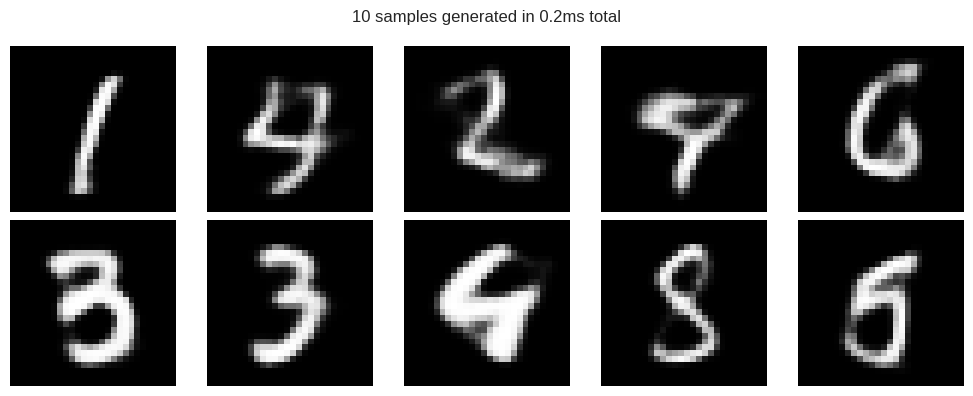

In [ ]:
# Demonstrate VAE speed advantage
import time

@torch.no_grad()
def benchmark_generation_speed(model, num_samples=100):
    """Benchmark VAE generation speed."""
    model.eval()

    # Warm up GPU
    _ = model.sample(1)

    # Benchmark
    start_time = time.time()
    samples = model.sample(num_samples)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    end_time = time.time()

    total_time = end_time - start_time
    time_per_sample = total_time / num_samples * 1000  # in milliseconds

    print(f"VAE Generation Speed Benchmark:")
    print(f"  Generated {num_samples} samples in {total_time:.3f} seconds")
    print(f"  Average time per sample: {time_per_sample:.2f} ms")
    print(f"  Samples per second: {num_samples/total_time:.1f}")

    print(f"\nComparison with DDPMs:")
    print(f"  DDPMs typically take 1-10 seconds per sample (1000-10000x slower)")
    print(f"  This speed advantage makes VAEs suitable for real-time applications")

    # Show some samples
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()
    for i in range(10):
        axes[i].imshow(samples[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(f'10 samples generated in {10*time_per_sample:.1f}ms total', fontsize=12)
    plt.tight_layout()
    plt.show()

benchmark_generation_speed(model)

## 7. Interactive Experiments

Let's explore some interactive aspects of VAEs!

In [ ]:
# Explore the effect of β (KL weight) on generation
@torch.no_grad()
def explore_beta_vae(train_loader, test_loader, betas=[0.1, 0.5, 1.0, 2.0, 5.0]):
    """Train VAEs with different β values and compare."""

    results = {}

    for beta in betas:
        print(f"\nTraining VAE with β={beta}...")

        # Create and train model
        model_beta = VAE(latent_dim=10).to(device)
        optimizer = optim.Adam(model_beta.parameters(), lr=1e-3)

        # Quick training (3 epochs)
        for epoch in range(3):
            model_beta.train()
            for data, _ in train_loader:
                data = data.to(device)
                optimizer.zero_grad()

                x_recon, mu, logvar = model_beta(data)
                loss, recon_loss, kl_loss = vae_loss(x_recon, data, mu, logvar, beta)

                loss.backward()
                optimizer.step()

        model_beta.eval()
        results[beta] = model_beta

    # Visualize results
    fig, axes = plt.subplots(len(betas), 6, figsize=(12, len(betas)*2))

    # Get test sample for reconstruction
    test_data, _ = next(iter(test_loader))
    test_sample = test_data[:1].to(device)

    for i, beta in enumerate(betas):
        model_beta = results[beta]

        # Original
        axes[i, 0].imshow(test_sample.cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Original' if i == 0 else '')
        axes[i, 0].set_ylabel(f'β={beta}', fontsize=12)
        axes[i, 0].axis('off')

        # Reconstruction
        recon, _, _ = model_beta(test_sample)
        axes[i, 1].imshow(recon.cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Reconstruction' if i == 0 else '')
        axes[i, 1].axis('off')

        # Generated samples
        samples = model_beta.sample(4)
        for j in range(4):
            axes[i, j+2].imshow(samples[j].cpu().squeeze(), cmap='gray')
            axes[i, j+2].set_title(f'Sample {j+1}' if i == 0 else '')
            axes[i, j+2].axis('off')

    plt.suptitle('Effect of β on VAE: Higher β → More Regularization → Smoother Latent Space', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nObservations:")
    print("- Low β (0.1): Better reconstruction, but less diverse generation")
    print("- Standard β (1.0): Balanced trade-off")
    print("- High β (5.0): Worse reconstruction, but more structured latent space")

# Note: This is computationally intensive, uncomment to run
# explore_beta_vae(train_loader, test_loader)

AttributeError: 'Axes' object has no attribute 'set_text'

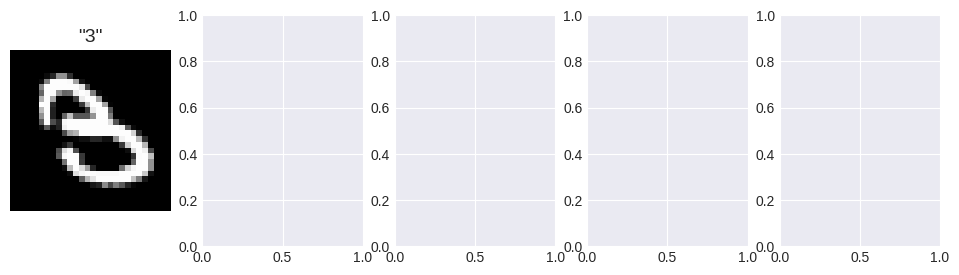

In [ ]:
# Arithmetic in latent space
@torch.no_grad()
def latent_arithmetic(model, loader):
    """Demonstrate arithmetic operations in latent space."""
    model.eval()

    # Find examples of digits 3, 5, and 7
    imgs = {}
    target_digits = [3, 5, 7]

    for data, labels in loader:
        for digit in target_digits:
            if digit not in imgs:
                idx = (labels == digit).nonzero(as_tuple=True)[0]
                if len(idx) > 0:
                    imgs[digit] = data[idx[0:1]].to(device)

        if len(imgs) == len(target_digits):
            break

    # Encode to latent space
    latents = {}
    for digit, img in imgs.items():
        mu, _ = model.encode(img)
        latents[digit] = mu

    # Perform arithmetic: "3" + "5" - "7" = ?
    z_result = latents[3] + latents[5] - latents[7]
    img_result = model.decode(z_result)

    # Visualize
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))

    axes[0].imshow(imgs[3].cpu().squeeze(), cmap='gray')
    axes[0].set_title('"3"', fontsize=14)
    axes[0].axis('off')

    axes[1].set_text(0.5, 0.5, '+', fontsize=20, ha='center', va='center')
    axes[1].axis('off')

    axes[2].imshow(imgs[5].cpu().squeeze(), cmap='gray')
    axes[2].set_title('"5"', fontsize=14)
    axes[2].axis('off')

    axes[3].set_text(0.5, 0.5, '-', fontsize=20, ha='center', va='center')
    axes[3].axis('off')

    axes[3].imshow(imgs[7].cpu().squeeze(), cmap='gray')
    axes[3].set_title('"7"', fontsize=14)
    axes[3].axis('off')

    axes[4].set_text(0.5, 0.5, '=', fontsize=20, ha='center', va='center')
    axes[4].axis('off')

    axes[4].imshow(img_result.cpu().squeeze(), cmap='gray')
    axes[4].set_title('Result', fontsize=14)
    axes[4].axis('off')

    plt.suptitle('Arithmetic in VAE Latent Space', fontsize=16)
    plt.tight_layout()
    plt.show()

    print("Note: VAE latent spaces often exhibit linear structure,")
    print("allowing meaningful arithmetic operations on encoded representations!")

latent_arithmetic(model, test_loader)

## Conclusion

Congratulations! You've successfully implemented and explored Variational Autoencoders. Let's recap what we've learned:

### Key Takeaways

1. **VAE Architecture**: Encoder → Latent (μ, σ) → Reparameterization → Decoder
2. **Training**: Balancing reconstruction quality with latent space regularization
3. **Capabilities**: Fast generation, meaningful interpolation, interpretable representations
4. **Applications**: From anomaly detection to creative generation
5. **Trade-offs**: VAEs offer speed and interpretability, DDPMs offer quality

### The Power of Probabilistic Thinking

VAEs demonstrate how probabilistic modeling can turn the generation problem into a well-defined optimization task. By learning to encode data as distributions rather than points, VAEs create smooth, meaningful latent spaces that enable powerful applications.

### Next Steps

- Try different architectures (ConvVAE, VQ-VAE, etc.)
- Experiment with other datasets (CelebA, CIFAR-10)
- Explore advanced variants (β-VAE, Factor-VAE, TC-VAE)
- Combine with other models (VAE-GAN, VAE + Flow models)

Remember: VAEs and DDPMs aren't competitors - they're complementary tools in your generative AI toolkit!

In [ ]:
# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared!")